=== Cycle Extraction ===
Normal   : 475 cycles / 338 segments
Abnormal : 8 cycles / 6 segments

=== Normal Pump Operating-Response Model ===
AI0: slope=0.000404, intercept=0.017704, R²=0.4962, residual SD=0.015470
AI1: slope=0.001490, intercept=-0.075739, R²=0.9390, residual SD=0.014443

Normal Train AI2 RMS Range : 80.221 ~ 193.626

=== Normal Holdout Validation ===
Train cycles   : 330
Holdout cycles : 145
Current OOD    : 0
PORD > 3.0 FPR : 0.0069

=== Low-RMS Normal False Alarm Check ===
Other   | n=131 | PORD break rate=0.0076
Low-RMS | n= 14 | PORD break rate=0.0000

=== Abnormal Full-Cycle PORD ===
segment_id  cycle_id  duration_sec  AI2_Current_rms  AI2_Current_OOD  AI0_response_z  AI1_response_z   PORD  PORD_break
     A0001         1           1.3           97.814            False          31.149          15.034 31.149        True
     A0001         2           1.3          110.189            False          27.243          14.930 27.243        True
     A0006         1       

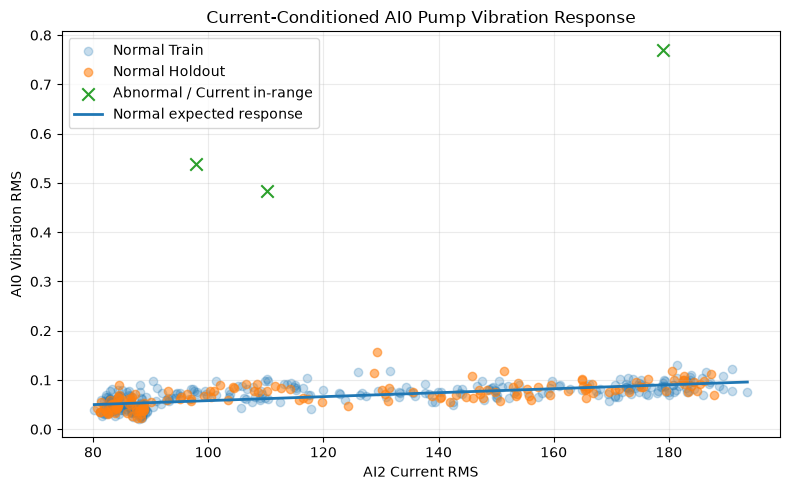

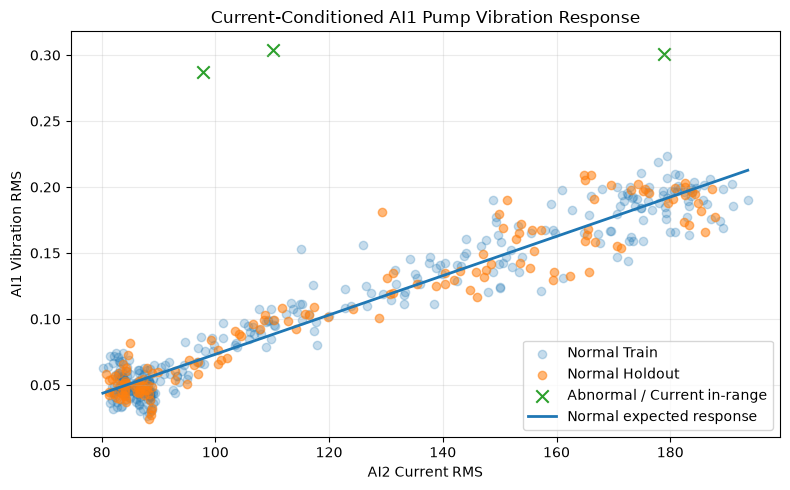

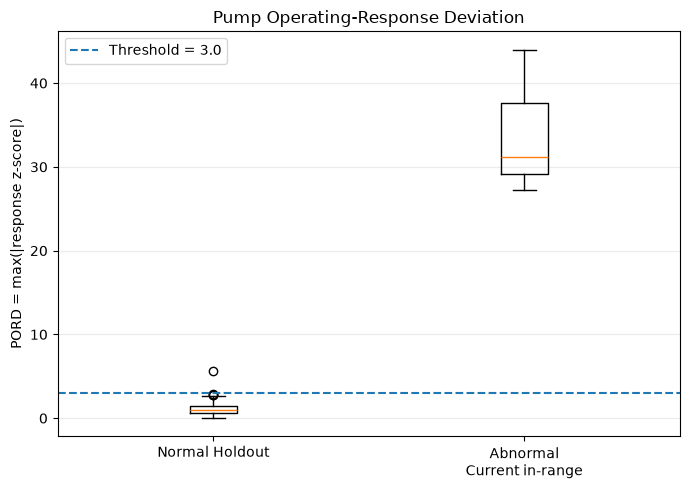


Saved to: c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_Physics_Informed\01_PORD_results


In [2]:
# PORD: AI2 Current 운전상태 대비 AI0/AI1 진동응답 이탈도를 검증한다.
# Normal cycle에서 Current RMS → Vibration RMS 정상관계를 학습하고 residual z-score를 계산한다.
# 두 진동채널 중 더 큰 이탈을 Pump Operating-Response Deviation(PORD)으로 정의한다.
# 실제 에너지·압력·힘이 아니라 current-conditioned pump vibration response 지표다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

MIN_SEG_ROWS, MIN_PEAK_DIST = 30, 12
TEST_SIZE, RANDOM_STATE, Z_THRESHOLD = .30, 42, 3.0
LOW_RMS_START, LOW_RMS_END = 3600, 4300


# ------------------------------------------------------------
# 1. 경로
# ------------------------------------------------------------
def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass

    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists(): return p
    raise FileNotFoundError("data/processed/preprocessed_data.csv를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
OUT = ROOT / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results"
OUT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Normal / Abnormal Cycle 추출
# ------------------------------------------------------------
def rms(x): return float(np.sqrt(np.mean(np.asarray(x, float) ** 2)))

def extract_cycles(data, source):
    rows = []

    for seg, g in data[data.source == source].groupby("segment_id", sort=False):
        g = g.sort_values("pos_in_seg").reset_index(drop=True)
        if len(g) < MIN_SEG_ROWS: continue

        cur = g.AI2_Current.to_numpy(float)
        smooth = pd.Series(cur).rolling(3, center=True, min_periods=1).median().to_numpy()
        prom = max(np.std(smooth, ddof=1) * .5, np.finfo(float).eps)
        peaks, _ = find_peaks(smooth, distance=MIN_PEAK_DIST, prominence=prom)

        for cid, (s, e) in enumerate(zip(peaks[:-1], peaks[1:]), 1):
            if e - s < MIN_PEAK_DIST: continue
            c = g.iloc[s:e + 1]
            duration = c.elapsed_sec.iloc[-1] - c.elapsed_sec.iloc[0]
            if duration <= 0: continue

            rows.append({
                "source": source, "segment_id": seg, "cycle_id": cid,
                "duration_sec": float(duration), "n_samples": len(c),
                "start_elapsed_sec": float(c.elapsed_sec.iloc[0]),
                "AI0_Vibration_rms": rms(c.AI0_Vibration),
                "AI1_Vibration_rms": rms(c.AI1_Vibration),
                "AI2_Current_rms": rms(c.AI2_Current)
            })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 3. Normal Current → Vibration 정상응답 모델
# ------------------------------------------------------------
def fit_response_models(train):
    models, refs = {}, {}
    X = train[["AI2_Current_rms"]].to_numpy()

    for ch in ["AI0", "AI1"]:
        y = train[f"{ch}_Vibration_rms"].to_numpy()
        model = LinearRegression().fit(X, y)
        resid = y - model.predict(X)

        models[ch] = model
        refs[ch] = {
            "slope": model.coef_[0], "intercept": model.intercept_,
            "r2": model.score(X, y), "residual_mean": resid.mean(),
            "residual_std": resid.std(ddof=1)
        }

    return models, refs


# ------------------------------------------------------------
# 4. PORD 계산
# ------------------------------------------------------------
def add_pord(df, models, refs, cur_min, cur_max):
    out = df.copy()
    X = out[["AI2_Current_rms"]].to_numpy()
    out["AI2_Current_OOD"] = ~out.AI2_Current_rms.between(cur_min, cur_max)

    for ch in ["AI0", "AI1"]:
        pred = models[ch].predict(X)
        resid = out[f"{ch}_Vibration_rms"].to_numpy() - pred
        ref = refs[ch]

        out[f"{ch}_expected_rms"] = pred
        out[f"{ch}_response_residual"] = resid
        out[f"{ch}_response_z"] = (resid - ref["residual_mean"]) / ref["residual_std"]

    out["PORD_raw"] = np.maximum(out.AI0_response_z.abs(), out.AI1_response_z.abs())
    out["PORD"] = out.PORD_raw.mask(out.AI2_Current_OOD)
    out["PORD_break"] = (~out.AI2_Current_OOD) & (out.PORD > Z_THRESHOLD)
    return out


# ------------------------------------------------------------
# 5. 데이터 / Cycle
# ------------------------------------------------------------
data = pd.read_csv(DATA_PATH)
normal = extract_cycles(data, "normal")
abnormal = extract_cycles(data, "abnormal")

print("=== Cycle Extraction ===")
print(f"Normal   : {len(normal)} cycles / {normal.segment_id.nunique()} segments")
print(f"Abnormal : {len(abnormal)} cycles / {abnormal.segment_id.nunique()} segments")


# ------------------------------------------------------------
# 6. Normal Train / Holdout
# ------------------------------------------------------------
segments = normal.segment_id.unique()
train_seg, holdout_seg = train_test_split(
    segments, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

train = normal[normal.segment_id.isin(train_seg)].copy()
holdout = normal[normal.segment_id.isin(holdout_seg)].copy()

models, refs = fit_response_models(train)
cur_min, cur_max = train.AI2_Current_rms.min(), train.AI2_Current_rms.max()

train = add_pord(train, models, refs, cur_min, cur_max)
holdout = add_pord(holdout, models, refs, cur_min, cur_max)
abnormal = add_pord(abnormal, models, refs, cur_min, cur_max)


# ------------------------------------------------------------
# 7. 정상 관계 / Holdout FPR
# ------------------------------------------------------------
print("\n=== Normal Pump Operating-Response Model ===")
for ch in ["AI0", "AI1"]:
    r = refs[ch]
    print(f"{ch}: slope={r['slope']:.6f}, intercept={r['intercept']:.6f}, "
          f"R²={r['r2']:.4f}, residual SD={r['residual_std']:.6f}")

print(f"\nNormal Train AI2 RMS Range : {cur_min:.3f} ~ {cur_max:.3f}")

holdout_valid = holdout[~holdout.AI2_Current_OOD]

print("\n=== Normal Holdout Validation ===")
print(f"Train cycles   : {len(train)}")
print(f"Holdout cycles : {len(holdout)}")
print(f"Current OOD    : {holdout.AI2_Current_OOD.sum()}")
print(f"PORD > {Z_THRESHOLD:.1f} FPR : {holdout_valid.PORD_break.mean():.4f}")


# ------------------------------------------------------------
# 8. Low-RMS Normal 오경보 확인
# ------------------------------------------------------------
holdout["Low_RMS_candidate"] = holdout.start_elapsed_sec.between(
    LOW_RMS_START, LOW_RMS_END
)

print("\n=== Low-RMS Normal False Alarm Check ===")
for flag, g in holdout.groupby("Low_RMS_candidate"):
    g = g[~g.AI2_Current_OOD]
    print(f"{'Low-RMS' if flag else 'Other':7s} | n={len(g):3d} | "
          f"PORD break rate={g.PORD_break.mean():.4f}")


# ------------------------------------------------------------
# 9. Abnormal Full-cycle 평가
# ------------------------------------------------------------
abnormal_valid = abnormal[~abnormal.AI2_Current_OOD]

cols = [
    "segment_id", "cycle_id", "duration_sec", "AI2_Current_rms",
    "AI2_Current_OOD", "AI0_response_z", "AI1_response_z",
    "PORD", "PORD_break"
]

print("\n=== Abnormal Full-Cycle PORD ===")
print(abnormal[cols].round(3).to_string(index=False))

print("\n=== Abnormal Summary ===")
print(f"Full cycles    : {len(abnormal)}")
print(f"Current OOD    : {abnormal.AI2_Current_OOD.sum()}")
print(f"PORD evaluable : {len(abnormal_valid)}")
print(f"PORD break     : {abnormal_valid.PORD_break.sum()} / {len(abnormal_valid)}")


# ------------------------------------------------------------
# 10. Current-conditioned Response 시각화
# ------------------------------------------------------------
def plot_response(ch):
    x = np.linspace(cur_min, cur_max, 200).reshape(-1, 1)

    plt.figure(figsize=(8, 5))
    plt.scatter(train.AI2_Current_rms, train[f"{ch}_Vibration_rms"], alpha=.25, label="Normal Train")
    plt.scatter(holdout.AI2_Current_rms, holdout[f"{ch}_Vibration_rms"], alpha=.55, label="Normal Holdout")
    plt.scatter(abnormal_valid.AI2_Current_rms, abnormal_valid[f"{ch}_Vibration_rms"],
                marker="x", s=80, label="Abnormal / Current in-range")
    plt.plot(x[:, 0], models[ch].predict(x), linewidth=2, label="Normal expected response")

    plt.xlabel("AI2 Current RMS")
    plt.ylabel(f"{ch} Vibration RMS")
    plt.title(f"Current-Conditioned {ch} Pump Vibration Response")
    plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
    plt.savefig(OUT / f"PORD_{ch}_response.png", dpi=150)
    plt.show()

for ch in ["AI0", "AI1"]: plot_response(ch)


# ------------------------------------------------------------
# 11. PORD 분포
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.boxplot(
    [holdout_valid.PORD.dropna(), abnormal_valid.PORD.dropna()],
    tick_labels=["Normal Holdout", "Abnormal\nCurrent in-range"]
)

plt.axhline(Z_THRESHOLD, linestyle="--", label=f"Threshold = {Z_THRESHOLD}")
plt.ylabel("PORD = max(|response z-score|)")
plt.title("Pump Operating-Response Deviation")
plt.legend(); plt.grid(axis="y", alpha=.25); plt.tight_layout()
plt.savefig(OUT / "PORD_normal_vs_abnormal.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 12. 결과 저장
# ------------------------------------------------------------
train.to_csv(OUT / "normal_train_pord.csv", index=False)
holdout.to_csv(OUT / "normal_holdout_pord.csv", index=False)
abnormal.to_csv(OUT / "abnormal_fullcycle_pord.csv", index=False)
pd.DataFrame(refs).T.to_csv(OUT / "pord_model_reference.csv")

print(f"\nSaved to: {OUT}")

=== Normal Operating Support ===
Reference Cycle Time : 1.70 s
Timing Support       : 1.60 ~ 1.70 s
Current Support      : 81.363 ~ 190.911

=== Normal Holdout Support ===
Support_State
Timing IN + Current IN     141
Timing IN + Current OUT      4

=== Abnormal Operating Support Map ===
segment_id  cycle_id  duration_sec  Timing_Deviation  AI2_Current_rms  Timing_IN  Current_IN            Support_State   PORD  PORD_break  PORD_Strict_Evaluable
     A0001         1           1.3             0.235           97.814      False        True  Timing OUT + Current IN 31.149        True                  False
     A0001         2           1.3             0.235          110.189      False        True  Timing OUT + Current IN 27.243        True                  False
     A0006         1           1.5             0.118          178.896      False        True  Timing OUT + Current IN 43.982        True                  False
     A0011         1           1.6             0.059           52.919   

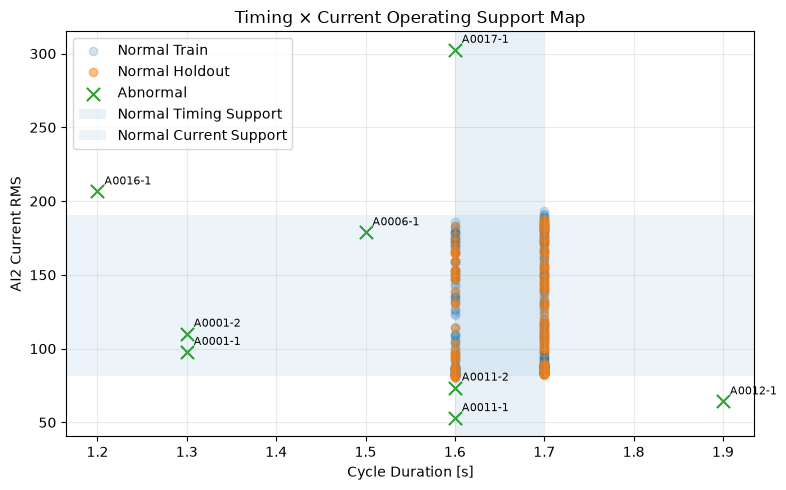

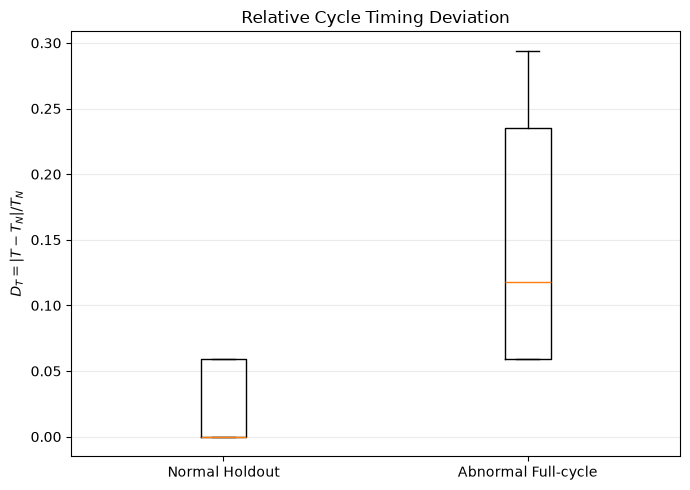


Saved to: c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_Physics_Informed\02_Operating_Support_results


In [3]:
# Normal Train으로 Cycle Timing과 AI2 Current의 정상 운전영역을 고정한다.
# Abnormal cycle을 Timing IN/OUT × Current IN/OUT 4가지 상태로 분류한다.
# Timing과 Current가 모두 정상범위인 cycle에서만 PORD를 독립적 응답이탈로 해석한다.
# PORD가 기존 Timing anomaly와 중복되는지 검증하는 단계다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Q_LO, Q_HI = .005, .995


# ------------------------------------------------------------
# 1. 경로 / PORD 결과 불러오기
# ------------------------------------------------------------
def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results").exists(): return p
    raise FileNotFoundError("01_PORD_results 폴더를 찾지 못했습니다.")

ROOT = find_root()
PORD_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results"
OUT = ROOT / "KAMP/05_EDA/05_Physics_Informed/02_Operating_Support_results"
OUT.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(PORD_DIR / "normal_train_pord.csv")
holdout = pd.read_csv(PORD_DIR / "normal_holdout_pord.csv")
abnormal = pd.read_csv(PORD_DIR / "abnormal_fullcycle_pord.csv")


# ------------------------------------------------------------
# 2. Normal Train 정상 운전영역 고정
# ------------------------------------------------------------
T_REF = train.duration_sec.median()
T_LO, T_HI = train.duration_sec.quantile([Q_LO, Q_HI])
I_LO, I_HI = train.AI2_Current_rms.quantile([Q_LO, Q_HI])

def add_support(df):
    out = df.copy()
    out["Timing_Deviation"] = (out.duration_sec - T_REF).abs() / T_REF
    out["Timing_IN"] = out.duration_sec.between(T_LO, T_HI)
    out["Current_IN"] = out.AI2_Current_rms.between(I_LO, I_HI)

    out["Support_State"] = np.select(
        [
            out.Timing_IN & out.Current_IN,
            ~out.Timing_IN & out.Current_IN,
            out.Timing_IN & ~out.Current_IN
        ],
        [
            "Timing IN + Current IN",
            "Timing OUT + Current IN",
            "Timing IN + Current OUT"
        ],
        default="Timing OUT + Current OUT"
    )

    out["PORD_Strict_Evaluable"] = out.Timing_IN & out.Current_IN
    return out

train = add_support(train)
holdout = add_support(holdout)
abnormal = add_support(abnormal)


# ------------------------------------------------------------
# 3. 정상영역 출력
# ------------------------------------------------------------
print("=== Normal Operating Support ===")
print(f"Reference Cycle Time : {T_REF:.2f} s")
print(f"Timing Support       : {T_LO:.2f} ~ {T_HI:.2f} s")
print(f"Current Support      : {I_LO:.3f} ~ {I_HI:.3f}")

print("\n=== Normal Holdout Support ===")
print(holdout.Support_State.value_counts().to_string())


# ------------------------------------------------------------
# 4. Abnormal 4분류
# ------------------------------------------------------------
cols = [
    "segment_id", "cycle_id", "duration_sec", "Timing_Deviation",
    "AI2_Current_rms", "Timing_IN", "Current_IN",
    "Support_State", "PORD", "PORD_break", "PORD_Strict_Evaluable"
]

print("\n=== Abnormal Operating Support Map ===")
print(abnormal[cols].round(3).to_string(index=False))

print("\n=== Abnormal Support Summary ===")
print(abnormal.Support_State.value_counts().to_string())

strict = abnormal[abnormal.PORD_Strict_Evaluable]

print("\n=== Strict PORD Evaluation ===")
print(f"Abnormal full cycles       : {len(abnormal)}")
print(f"Timing + Current both IN   : {len(strict)}")

if len(strict):
    print(f"PORD break                 : {strict.PORD_break.sum()} / {len(strict)}")
else:
    print("PORD 독립 검증 가능한 abnormal cycle 없음")


# ------------------------------------------------------------
# 5. Timing × Current Support Map
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    train.duration_sec, train.AI2_Current_rms,
    alpha=.20, label="Normal Train"
)

plt.scatter(
    holdout.duration_sec, holdout.AI2_Current_rms,
    alpha=.50, label="Normal Holdout"
)

plt.scatter(
    abnormal.duration_sec, abnormal.AI2_Current_rms,
    marker="x", s=90, label="Abnormal"
)

plt.axvspan(T_LO, T_HI, alpha=.10, label="Normal Timing Support")
plt.axhspan(I_LO, I_HI, alpha=.08, label="Normal Current Support")

for _, r in abnormal.iterrows():
    plt.annotate(
        f"{r.segment_id}-{int(r.cycle_id)}",
        (r.duration_sec, r.AI2_Current_rms),
        xytext=(5, 5), textcoords="offset points", fontsize=8
    )

plt.xlabel("Cycle Duration [s]")
plt.ylabel("AI2 Current RMS")
plt.title("Timing × Current Operating Support Map")
plt.legend()
plt.grid(alpha=.25)
plt.tight_layout()
plt.savefig(OUT / "timing_current_support_map.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 6. Timing Deviation 비교
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        holdout.Timing_Deviation,
        abnormal.Timing_Deviation
    ],
    tick_labels=["Normal Holdout", "Abnormal Full-cycle"]
)

plt.ylabel(r"$D_T = |T-T_N| / T_N$")
plt.title("Relative Cycle Timing Deviation")
plt.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.savefig(OUT / "timing_deviation.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 7. 저장
# ------------------------------------------------------------
holdout.to_csv(OUT / "normal_holdout_support.csv", index=False)
abnormal.to_csv(OUT / "abnormal_operating_support.csv", index=False)

summary = abnormal.Support_State.value_counts().rename_axis("Support_State").reset_index(name="count")
summary.to_csv(OUT / "abnormal_support_summary.csv", index=False)

print(f"\nSaved to: {OUT}")